# 04: What it is worth in money

**The question this notebook answers:** notebook 03 found that the model beats the market two days
out, on probability. Does that survive real fills? Does it survive two months the model never saw?
And is there a faster way to use the same information, by trading the moment a forecast is
published?

The three answers come from the tape backtest in `weather_edge.backtest`, from the one-shot holdout
run whose output is committed in `reports/`, and from the timing study in `weather_edge.timing`.
The backtest runs live here for London. The holdout is read from the report and not run again,
because a holdout scored twice is not a holdout.

**The answer it arrives at:** London at noon makes about 5c a share on the fills the tape proves,
110 USD over eighteen months at five shares an order, and loses money once winning fills are
discounted. Seventy percent of the model's expected edge is adverse selection. On the holdout the
edge is gone. And prices do not react to forecast publications at all. No live money.

## Setup

In [1]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from weather_edge import backtest, config, plots

con = duckdb.connect(str(config.RESEARCH_DB), read_only=True)
con.execute("SET enable_progress_bar=false")
con.execute(f"ATTACH '{config.PRICES_DB}' AS px (READ_ONLY)")
con.execute(f"ATTACH '{config.FORECASTS_DB}' AS fc (READ_ONLY)")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## Orders, and fills that are never assumed

**The strategy is the simplest thing that uses the signal.** At noon two days before the day, for
every bucket where the model's probability is at least 10c away from the last traded price, rest a
maker order for five shares (the exchange minimum) on the side the model favours, one cent inside
the last price, for 24 hours. Buy YES when the model is higher than the market, buy NO when it is
lower.

**Whether an order fills is read off the trade tape, not assumed.** Three rules:

- **touch**: a taker print at or through the order price during the 24 hours fills up to the printed
  volume.
- **through**: only prints strictly beyond the price count. The whole level was cleared, so a resting
  order there was filled whatever its place in the queue. This is the conservative one.
- **haircut**: the same, with every winning fill halved. Fills come easier when the model is wrong,
  and this is a crude allowance for that.

Makers pay no fee and the rebate is ignored. This takes a few minutes: it refits the model day by
day for London, then joins every order to the fills in its window.

In [2]:
london = backtest.run(con, "EGLC", 12)
orders = london["orders"]

print("buckets with a price at the decision:", london["signal_buckets"])
print("orders:", len(orders))
orders[["day", "side", "price", "market_p", "p_emos", "outcome", "touch_volume", "through_volume"]].head(8)

buckets with a price at the decision: 3118
orders: 1041


,day,side,price,market_p,p_emos,outcome,touch_volume,through_volume
0,2025-02-10,no,0.70,0.295,0.004737,0,0.00,0.00
1,2025-02-10,no,0.76,0.235,0.075987,0,52.88,52.88
2,2025-02-10,yes,0.04,0.055,0.420924,0,91.23,19.23
3,2025-02-10,yes,0.03,0.045,0.158273,0,71.04,71.04
4,2025-02-13,no,0.66,0.335,0.160065,0,19.03,19.03
5,2025-02-13,no,0.45,0.535,0.390934,1,189.63,149.51
6,2025-02-13,yes,0.19,0.200,0.324534,0,483.49,483.49
7,2025-02-14,no,0.59,0.400,0.283872,0,1060.88,1060.88


In [3]:
columns = ["fill_model", "orders", "orders_filled", "filled_shares", "pnl_usd", "pnl_c_per_share",
           "pnl_usd_per_order_ci_low", "pnl_usd_per_order_ci_high", "win_rate_filled",
           "expected_c_per_share_filled"]
london["total"][columns].round(3)

,fill_model,orders,orders_filled,filled_shares,pnl_usd,pnl_c_per_share,pnl_usd_per_order_ci_low,pnl_usd_per_order_ci_high,win_rate_filled,expected_c_per_share_filled
0,touch,1041,439,2122.250,121.205,5.711,0.101,0.453,0.572,18.580
1,through,1041,412,1992.970,110.322,5.536,0.078,0.447,0.573,18.596
2,touch_haircut,1041,439,1520.045,-103.835,-6.831,-0.365,-0.099,0.572,18.580
3,through_haircut,1041,412,1426.820,-101.347,-7.103,-0.386,-0.109,0.573,18.596


### What we got

**London at noon: 1,041 orders, 412 of them proven filled by a print through the level, +110 USD,
5.5c a share.** The 90% day-bootstrap interval on profit per order is +0.08 to +0.45 USD, above
zero. Touch fills agree at 5.7c. Both haircut rows are negative, around −7c a share.

That last row is the one to keep in mind. The through rule already proves each fill happened. The
haircut on top of it double counts, so it is harsher than reality. But a strategy that only works
when you believe every winning fill is one you would not want to fund.

## Which side does the work?

In [4]:
by_side = london["by_side"]
by_side[by_side.fill_model == "through"][["side"] + columns[1:]].round(3).reset_index(drop=True)

,side,orders,orders_filled,filled_shares,pnl_usd,pnl_c_per_share,pnl_usd_per_order_ci_low,pnl_usd_per_order_ci_high,win_rate_filled,expected_c_per_share_filled
0,no,914,313,1502.38,100.027,6.658,0.104,0.523,0.706,19.040
1,yes,127,99,490.59,10.294,2.098,-0.176,0.421,0.152,17.191


### The NO side

Bids on NO, placed when the market prices a bucket 10c above the model, win 71% of the time and
make 6.7c a share. Bids on YES, the underpriced buckets, fill often and win rarely. That matches
notebook 01: takers who sell a mid-priced bucket are the informed ones, and a resting NO order is
on the same side as them. A resting YES order is on the other side.

## Month by month

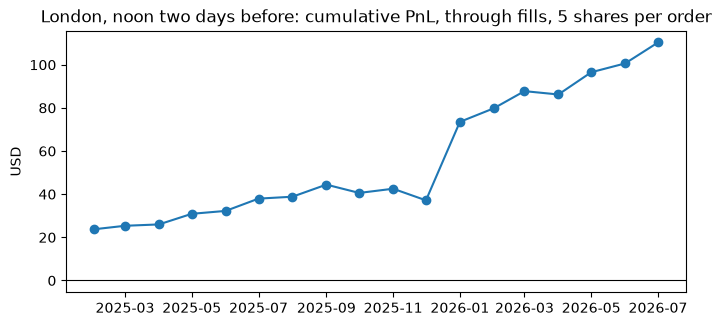

positive months: 15 of 18


,month,orders,orders_filled,pnl_usd,pnl_c_per_share,win_rate_filled
1,2025-02,26,19,23.76,26.57,0.63
5,2025-03,21,9,1.60,3.56,0.56
9,2025-04,28,10,0.63,1.51,0.50
13,2025-05,40,17,4.92,5.95,0.59
17,2025-06,100,13,1.35,2.44,0.69
21,2025-07,164,13,5.69,9.90,0.54
25,2025-08,94,10,0.89,2.39,0.50
29,2025-09,36,10,5.60,11.20,0.70
33,2025-10,26,6,-3.85,-12.83,0.50
37,2025-11,13,10,1.95,3.90,0.50


In [5]:
by_month = london["by_month"].sort_values("month")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.axhline(0, color="black", linewidth=0.8)
ax.plot(pd.to_datetime(by_month.month), by_month.pnl_usd.cumsum(), marker="o")
ax.set_ylabel("USD")
ax.set_title("London, noon two days before: cumulative PnL, through fills, 5 shares per order")
plt.show()

print("positive months:", int((by_month.pnl_usd > 0).sum()), "of", len(by_month))
by_month[["month", "orders", "orders_filled", "pnl_usd", "pnl_c_per_share", "win_rate_filled"]].round(2)

### Fifteen of eighteen months are positive, and the gain is not front-loaded

The losing months lose 1.5 to 5.4 USD. January 2026 and February 2025 are the best months, and May
to July 2026 are all positive. The line goes up, slowly. Fills after April 2026 are understated
because the trade dataset covers only about 80% of prints after that, so the last three months are
if anything better than shown.

## How much of the edge is adverse selection?

**The model knows what it expected to make on each order.** Comparing that with what the filled
orders actually made is a direct measure of how much the fills select against it.

In [6]:
filled = orders[orders.filled_through > 0]

expected = 100 * filled.expected_pnl_share.mean()
realised = 100 * filled.pnl_through.sum() / filled.filled_through.sum()

print("orders filled (through):", len(filled))
print(f"expected, c per share:  {expected:.1f}")
print(f"realised, c per share:  {realised:.1f}")
print(f"kept: {100 * realised / expected:.0f}%")

orders filled (through): 412
expected, c per share:  18.6
realised, c per share:  5.5
kept: 30%


### Seventy percent of the paper edge never arrives

The model expected 18.6c a share on the orders that filled and got 5.5c. The tape measures that
without any haircut: the orders that fill are the ones where the other side knew something. The
same 70% shows up in New York. It is the single most useful number in this notebook, because it says
what a probability edge is worth once someone has to take the other side.

## Capacity, and New York

**Size is not the limit.** The capacity column counts every share printed beyond the order levels
over the period.

In [7]:
total = london["total"].set_index("fill_model")
through = total.loc["through"]

print("shares printed beyond the levels:", int(through.capacity_shares))
print("shares filled at 5 per order:    ", int(through.filled_shares))
print("per filled order:                ", int(through.capacity_shares / through.orders_filled))

shares printed beyond the levels: 194578
shares filled at 5 per order:     1992
per filled order:                 472


In [8]:
# New York, from the committed backtest report (same code, run by `make train`)
tables = plots.read_tables(config.REPORTS / "phase7_backtest.md")

nyc = pd.concat(
    [table.assign(decision=f"New York {hour:02d}:00")
     for hour in (6, 12)
     for heading, table in tables
     if f"KLGA, decision {hour:02d}:00" in heading and "All orders" in heading],
)
nyc = nyc[nyc.fill_model.isin(["through", "through_haircut"])]
nyc[["decision"] + columns].round(3).reset_index(drop=True)

,decision,fill_model,orders,orders_filled,filled_shares,pnl_usd,pnl_c_per_share,pnl_usd_per_order_ci_low,pnl_usd_per_order_ci_high,win_rate_filled,expected_c_per_share_filled
0,New York 06:00,through,748,272,1311.990,56.402,4.299,-0.004,0.436,0.629,19.311
1,New York 06:00,through_haircut,748,272,901.300,-77.440,-8.592,-0.450,-0.115,0.629,19.311
2,New York 12:00,through,1279,564,2697.970,25.207,0.934,-0.115,0.201,0.562,20.054
3,New York 12:00,through_haircut,1279,564,1950.985,-226.777,-11.624,-0.528,-0.278,0.562,20.054


### About 470 shares per filled order, and New York is thin

London's levels saw 195,000 shares printed against 2,000 filled, so the order size could grow
tenfold before the through rule stopped describing reality. New York has the same shape with less
edge: +4.3c at 06:00 with an interval touching zero, +0.9c at noon, negative under the haircut.

That is the whole in-sample story. Two cities pass on probability, one passes on money, and it
passes narrowly.

## The holdout, once

**August and September 2026 were kept out of everything above.** Every choice, from the window
length to the calibration step to the 10c threshold, was made on data before 1 August. Then the
one configuration that had passed, two days out at noon in London and New York, was scored on the
holdout exactly once, with `python -m weather_edge model --holdout`. The output is committed and
this notebook reads it rather than running it again. The trade tape ends on 20 July, so the holdout
is a Brier test only.

In [9]:
def two_days_out(path, station):
    table = plots.market_tables(path, station)
    row = table[(table.lead == 3) & (table.model == "emos")].iloc[0]
    return {"buckets": int(row.buckets), "days": int(row.days),
            "brier_market": row.brier_market, "brier_model": row.brier_model,
            "n_disagree": int(row.n_disagree), "market_minus_model": row.market_minus_model_on_disagree,
            "ci_low": row.ci_low, "ci_high": row.ci_high}

holdout = pd.DataFrame([
    {"city": city, "period": period, **two_days_out(config.REPORTS / report, station)}
    for station, city in (("EGLC", "London"), ("KLGA", "New York"))
    for period, report in (("before 2026-08", "phase6_cities.md"), ("holdout 2026-08 to 09", "phase5_holdout.md"))
]).set_index(["city", "period"])
holdout.round(4)

buckets  days  brier_market  brier_model  n_disagree  market_minus_model  ci_low  ci_high
city     period                                                                                                          
London   before 2026-08            3111   364        0.1019       0.0877        1087              0.0423  0.0313   0.0525
         holdout 2026-08 to 09      627    57        0.0670       0.0666          69             -0.0072 -0.0355   0.0207
New York before 2026-08            3215   408        0.1079       0.1004        1332              0.0206  0.0112   0.0309
         holdout 2026-08 to 09      319    29        0.0624       0.0697          52             -0.0379 -0.0778   0.0053

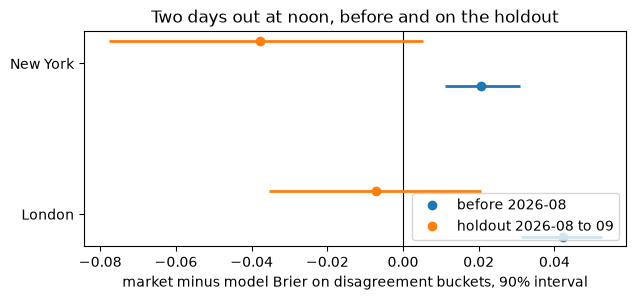

In [10]:
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.axvline(0, color="black", linewidth=0.8)
for shift, period in ((-0.15, "before 2026-08"), (0.15, "holdout 2026-08 to 09")):
    rows = holdout.xs(period, level="period")
    y = np.arange(len(rows)) + shift
    ax.hlines(y, rows.ci_low, rows.ci_high, linewidth=2, color="C0" if shift < 0 else "C1")
    ax.plot(rows.market_minus_model, y, "o", color="C0" if shift < 0 else "C1", label=period)
ax.set_yticks(range(len(rows)), rows.index)
ax.set_xlabel("market minus model Brier on disagreement buckets, 90% interval")
ax.set_title("Two days out at noon, before and on the holdout")
ax.legend(loc="lower right")
plt.show()

### The edge is not there

**London: −0.007 with an interval from −0.036 to +0.021. New York: −0.038, −0.078 to +0.005.**
Before the holdout the same configuration was at +0.042 and +0.021 with intervals well above zero.
The criterion "it holds on the holdout" is not met.

What moved is the market, not the model. Two days out the market's Brier is 0.067 in London and
0.062 in New York on the holdout, against 0.102 and 0.108 over the eighteen months before. It
disagrees with the model on 1.2 buckets a day where it used to be three. The model's own CRPS on
the holdout months is better than in sample, because August and September are easy months. New
York has only 29 holdout days with a quote at noon two days out, because of the 27-hour listing
window that summer, so its interval is wide. London's is not wide, and it contains zero.

A model built from public data in the autumn of 2026 arrives after the market has already
improved. Better to learn that from sixty held-out days than from a live account.

## Is there a faster trade in the same information?

**If the market followed the forecast runs with a lag, the moment a run was published would be a
window.** The timing study pairs every ECMWF and GFS publication with the change it made to the
run's forecast high, and with the change in the market-implied expected high from one hour before
publication to some minutes after. The slope of the second on the first is how much of a forecast
change passes through. A window 30 minutes before publication is the control. The study is
`python -m weather_edge timing`; this reads its report.

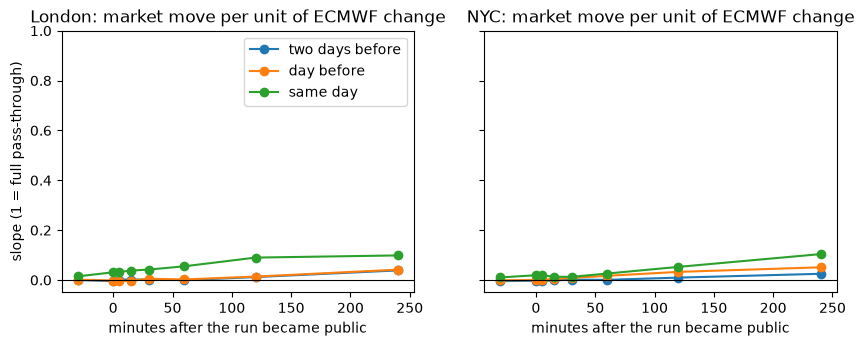

In [11]:
timing = {
    station: next(table for heading, table in plots.read_tables(config.REPORTS / "phase8_timing.md")
                  if heading.startswith(f"{station} |") and "slope" in table.columns)
    for station in ("EGLC", "KLGA")
}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for ax, (station, table) in zip(axes, timing.items()):
    ecmwf = table[table.model == "ecmwf"]
    for horizon in ("two days before", "day before", "same day"):
        curve = ecmwf[ecmwf.horizon == horizon].sort_values("minutes_after")
        ax.plot(curve.minutes_after, curve.slope, marker="o", label=horizon)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(-0.05, 1)
    ax.set_xlabel("minutes after the run became public")
    ax.set_title(f"{plots.STATION_NAMES[station]}: market move per unit of ECMWF change")
axes[0].set_ylabel("slope (1 = full pass-through)")
axes[0].legend()
plt.show()

In [12]:
london_timing = timing["EGLC"]
london_timing[(london_timing.model == "ecmwf") & (london_timing.minutes_after.isin([-30, 15, 240]))][
    ["horizon", "minutes_after", "runs", "slope", "corr", "mean_abs_market_move_big", "mean_abs_market_move_small", "share_same_sign_big"]
].round(3).reset_index(drop=True)

,horizon,minutes_after,runs,slope,corr,mean_abs_market_move_big,mean_abs_market_move_small,share_same_sign_big
0,day before,-30,2085,0.001,0.008,0.080,0.062,0.439
1,day before,15,2085,-0.002,-0.008,0.150,0.108,0.506
2,day before,240,2083,0.042,0.097,0.304,0.228,0.598
3,same day,-30,1080,0.015,0.079,0.085,0.077,0.576
4,same day,15,1078,0.038,0.127,0.175,0.135,0.583
5,same day,240,1024,0.099,0.124,0.458,0.348,0.603
6,two days before,-30,966,0.000,0.001,0.066,0.077,0.401
7,two days before,15,961,0.002,0.010,0.108,0.112,0.479
8,two days before,240,956,0.039,0.104,0.285,0.244,0.615


### Nothing passes through

A run that moves its forecast high by one degree moves the market's implied high by nothing in
the first 15 minutes on the days before the day, and by 0.04 of a degree on the day itself. After
four hours it is 0.04 to 0.10 of a degree. The sign of the market's move agrees with the model's
about half the time. The market drifts by a quarter to half a degree over four hours whether or
not the newest run changed anything: the two "mean absolute move" columns are nearly equal. The
control window before publication looks the same, so there is no leak either.

There is no lag to exploit because there is no reaction. Whatever the prices respond to, it is not
the global model runs as they become public.

In [13]:
con.close()

## What this notebook establishes

**The two-days-out edge is worth about 5c a share in London and nothing in New York, at fills the
tape proves.** It is 110 USD over eighteen months at the minimum order size, and negative once
winning fills are discounted. Seventy percent of what the model expected is lost to adverse
selection. The NO side carries all of it.

**It does not hold out of sample.** On August and September 2026 the market is as good as the model
two days out. The market got sharper during 2026 and the model did not.

**There is no timing trade.** Prices barely move when forecast runs are published, and not in a
direction you could use.

**So no live money.** I had set aside 200 USD and did not spend it. The measurement is the result:
pipelines that know when each forecast became public, a label that matches the venue's payouts, a
model scored point in time against prices, a backtest that never assumes a fill, and a holdout used
once. What the market does know, and where it gets it, is the open question, and the live collector
in this repository stores full order books to ask it.